# Using 'real' data 

In [1]:
#Install necessery Python packages

# Post spørring og få Pandas dataframe i retur
# benytter biblioteket pyjstat for JSON-stat

try:
    from pyjstat import pyjstat
    import requests
except:
    !pip install pyjstat
    from pyjstat import pyjstat
    !pip install requests
    import requests

# Import necessery Python packages
import pandas as pd # For data manipulation
import matplotlib.pyplot as plt # Import package for plotting

## Loading the data

Here we follow step by step how the data was loaded. Feel free to skip this section!

Loading (installing) necessery Python packages:


1. Follow the link to find the data on CO2-emission from different sectors: https://www.ssb.no/statbank/table/13931/
2. Select the variables you are intersted in, see example below

![Screenshot](Screenshot_1.PNG)


You can now vew this data as a table online. We can load it direcly by posting a SSB API query and using couple of Python commands!

3. Next, we copy the table URL and JASON query, and load the data (in json-stat2 format).

![Screenshot](Screenshot_2.PNG)


In [2]:
POST_URL = 'https://data.ssb.no/api/v0/no/table/13931/'
payload ={
  "query": [
    {
      "code": "UtslpTilLuft",
      "selection": {
        "filter": "vs:UtslpKildeA01",
        "values": [
          "0",
          "1",
          "2",
          "3",
          "4",
          "5",
          "6",
          "7",
          "9"
        ]
      }
    },
    {
      "code": "UtslpEnergivare",
      "selection": {
        "filter": "item",
        "values": [
          "VT0"
        ]
      }
    },
    {
      "code": "UtslpKomp",
      "selection": {
        "filter": "item",
        "values": [
          "A10"
        ]
      }
    },
    {
      "code": "ContentsCode",
      "selection": {
        "filter": "item",
        "values": [
          "UtslippCO2ekvival"
        ]
      }
    }
  ],
  "response": {
    "format": "json-stat2"
  }
}

resultat = requests.post(POST_URL, json = payload)

if resultat.status_code == 200:
    print('Data loaded successfully!')
else:
    print(f"Error: {resultat.status_code}")
    print(resultat.text)





Data loaded successfully!


If data loaded sucessfully, we need to tranform data to a format we can easily work with.

4. Turn JASON format `resultat` into a nice and tidy DataFrame `df`.



In [3]:
dataset = pyjstat.Dataset.read(resultat.text)
df = dataset.write('dataframe')
df.head() # print out the first 5 rows of the dataframe

,kilde (aktivitet),energiprodukt,komponent,statistikkvariabel,år,value
0,Alle kilder,I alt,Klimagasser i alt,"Utslipp til luft (1 000 tonn CO2-ekvivalenter,...",1990,51348
1,Alle kilder,I alt,Klimagasser i alt,"Utslipp til luft (1 000 tonn CO2-ekvivalenter,...",1991,48987
2,Alle kilder,I alt,Klimagasser i alt,"Utslipp til luft (1 000 tonn CO2-ekvivalenter,...",1992,47450
3,Alle kilder,I alt,Klimagasser i alt,"Utslipp til luft (1 000 tonn CO2-ekvivalenter,...",1993,49379
4,Alle kilder,I alt,Klimagasser i alt,"Utslipp til luft (1 000 tonn CO2-ekvivalenter,...",1994,51331


## Exploring the loaded data

Let us explore and view the dataset. Type the following (one by one) in the code cells below

- `df` – to display the whole dataframe  
- `df.info()` – to display information about the dataframe  
- `df.head()` – to display the first 5 rows  
- `df.tail()` – to display the last 5 rows


In [4]:
# Type any of the commands below to see the data in the dataframe

Some of the columns are redunant, and could be simply removed. Which ones?

In [5]:
#Let's count the number of occurrences of each unique value in another column of your DataFrame df.




That is right, we can simply drop 'energiprodukt', 'komponent', 'statistikkvariabel' columns:

In [6]:
df_cleaned = df.drop(columns=['energiprodukt', 'komponent', 'statistikkvariabel'])
df_cleaned


,kilde (aktivitet),år,value
0,Alle kilder,1990,51348
1,Alle kilder,1991,48987
2,Alle kilder,1992,47450
3,Alle kilder,1993,49379
4,Alle kilder,1994,51331
...,...,...,...
301,Andre kilder,2019,2398
302,Andre kilder,2020,2341
303,Andre kilder,2021,2294
304,Andre kilder,2022,2242


We can also reshape our dataframe so that each entry tells you the emission value for a specific source and year.

In [7]:
# Pivot the table: year as index, kilder as columns, values filled in
data = df_cleaned.pivot(index='år', columns='kilde (aktivitet)', values='value')
data.title = "Utslipp til luft (1 000 tonn CO2-ekvivalenter)"
data.head()


kilde (aktivitet),Alle kilder,Andre kilder,Energiforsyning,Industri og bergverk,Jordbruk,"Luftfart, sjøfart, fiske, motorredskaper m.m.",Olje- og gassutvinning,Oppvarming i andre næringer og husholdninger,Veitrafikk
år,,,,,,,,,
1990,51348,3084,341,19140,5050,5298,8254,2755,7426
1991,48987,2953,396,17620,4984,5109,8127,2490,7307
1992,47450,2924,390,15377,4956,5461,8728,2276,7338
1993,49379,2968,409,16325,4937,5664,9257,2308,7511
1994,51331,2999,466,17275,4944,5858,10053,2329,7408


Let's plot the emissions per year.

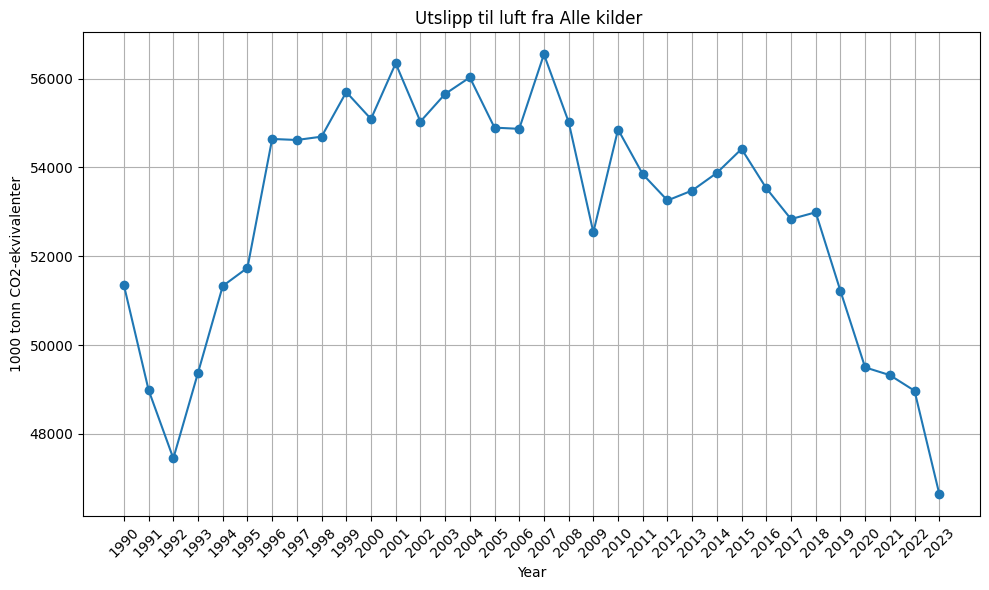

In [8]:
# plot value in the first column vs year

plt.figure(figsize=(10, 6))
#plt.plot(data.index, data['Alle kilder'], marker='o') # refer to the column by name
plt.plot(data.index, data.iloc[:, 0],  marker='o') # alternatively refer to the column by index


plt.title('Utslipp til luft fra Alle kilder ')
plt.xlabel('Year')
plt.ylabel( '1000 tonn CO2-ekvivalenter')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Modify the code below to plot emission from different sources per year.

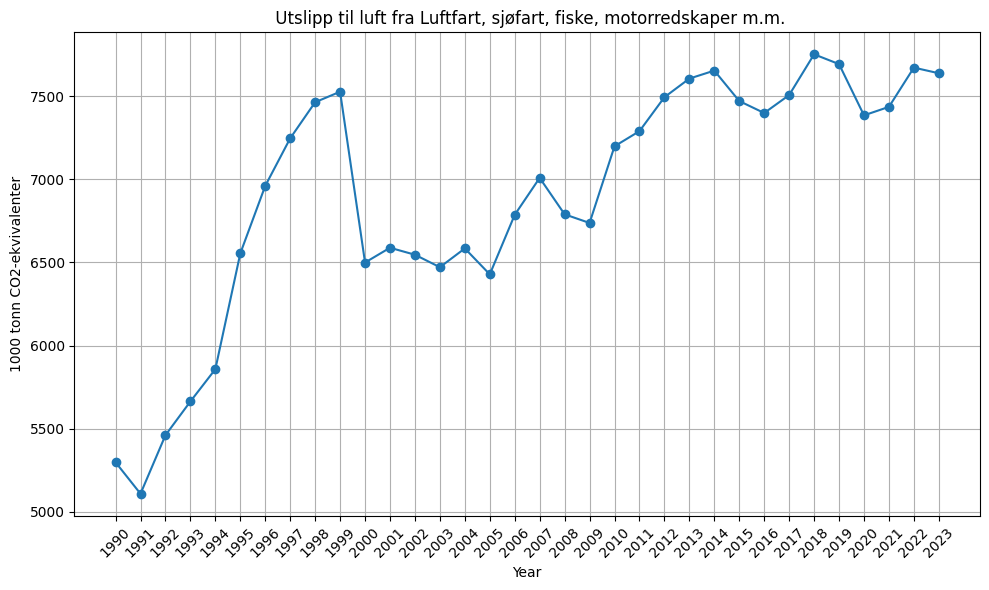

In [9]:

# Plot
plt.figure(figsize=(10, 6))
#plt.plot(data.index, data['Alle kilder'], marker='o') # refer to the column by name
plt.plot(data.index, data.iloc[:, 5],  marker='o') # alternatively refer to the column by index

plt.title(' Utslipp til luft fra '+ data.columns[5])
plt.xlabel('Year')
plt.ylabel( '1000 tonn CO2-ekvivalenter')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

